# Introducción
### **Descripción del problema**
La obesidad es reconocida en Argentina como un importante problema de salud pública. Existen campañas y programas, tanto a nivel nacional como provincial, que buscan reducir su prevalencia. Sin embargo, según datos de la Encuesta Nacional de Factores de Riesgo (ENFR), la tendencia sigue en aumento: en 2018, 6 de cada 10 personas presentaban exceso de peso, y 2 de esas 6 tenían obesidad.
Frente a este panorama, este proyecto propone mirar el problema desde otra perspectiva: ¿qué se dice sobre la obesidad en las redes sociales? ¿Cómo se construye el discurso público sobre el tema? Se parte de la idea de que factores culturales y sociales también pueden influir en este fenómeno y que, al analizarlos, podríamos entender mejor por qué sigue creciendo.
Para esto, trabajamos con un conjunto de datos compuesto por tweets que mencionan palabras clave relacionadas con la obesidad. Esta base incluye información como el contenido del tweet, la cantidad de likes, retweets, respuestas, citas, la fecha de publicación, el mes y la provincia desde donde fue publicado. A partir de este material, el proyecto busca explorar cómo se percibe y discute la obesidad en el espacio digital, qué temas predominan, qué emociones circulan y si existen diferencias regionales o temporales en la forma en que se habla del tema.

A partir de este dataset, se busca conocer un poco más sobre la percepción social de la obesidad, a partir de tópicos de discusión, patrones de interacción (likes, retweets, respuestas, etc) o análisis de sentimiento. Además, se pueden explorar posibles diferencias regionales o estacionales en los tweets y su relación con características propias del lenguaje. El proyecto también deja abierta la posibilidad de explorar otros aspectos relacionados con la temática y los distintos enfoques sobre la obesidad.


### **Problemas interesantes a abordar**

¿Cuáles son los principales temas de conversación sobre obesidad en Twitter?
¿Existen diferencias en el contenido compartido según la provincia? ¿Y según el mes?
¿Cómo varía el nivel de interacción (likes, retweets, respuestas) según el tipo de contenido del tweet?
¿Se pueden detectar períodos de mayor actividad relacionados con eventos específicos?
¿La cantidad de palabras que se utilizan en el tweet se asocia a un sentimiento negativo o positivo, o es indistinto?

### **Descripción del dataset**
Este repositorio contiene una base de datos con 11111 registros y 13 columnas recopilados de Twitter a partir de palabras clave sobre obesidad. La información fue extraída con el objetivo de analizar conversaciones en torno a la obesidad en Argentina, incluyendo interacciones, fechas, hashtags y datos geográficos. Para identificar la provincia de origen de los usuarios que generaron los tweets, se realizó un proceso de reconocimiento de localidades, ciudades y departamentos más relevantes y frecuentes a partir de la variable "location" asociada a cada usuario. Posteriormente, se asignó una provincia a cada tweet con base en esa información. En los casos en que un tweet presenta dos o más provincias identificadas, esto se debe a que el usuario mencionó múltiples lugares en su descripción de ubicación. Esta variable se denominó "pcia".

Más información disponible [aquí](https://github.com/eugehaluszka/mentoria_2025/tree/main/datasets).

## **Práctico 1**

En esta primera etapa, se trabajará con el dataset de tweets sobre obesidad para realizar un análisis exploratorio inicial. El objetivo es identificar patrones generales en los datos mediante visualizaciones: distribución de tweets por provincia o mes, volumen de interacciones (likes, retweets, respuestas), y posibles tendencias en la conversación pública. También se podrán contemplar la cantidad de palabras utilizadas en cada tweet, así como los términos más utilizados entre otros análisis descriptivos.
Se espera que este práctico permita conocer mejor la estructura de los datos y generar preguntas o hipótesis para análisis posteriores.

### **Cargando el dataset**

In [59]:
#Importar librerias de interes

from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import zipfile
import string
import spacy
import nltk
import re

%matplotlib inline

In [8]:
#Descargar la base desde el github

!wget -O base_obesidad_completa.zip "https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip"
with zipfile.ZipFile("base_obesidad_completa.zip", "r") as z:
    z.extractall()

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [54]:
#Abrir la base de datos
df = pd.read_csv("base_obesidad_completa.csv", encoding="utf-8-sig")
df_original = df.copy() #se genera copia
df.head(3)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2


### Conocer el dataset: **Análisis exploratorio**, aplicación de medidas resumen

#### Ejercicio 1.
Cargar dataset y describir brevemente su estructura:
* a. ¿Cuántas filas y columnas tiene?
* b. ¿Qué tipo de variables contiene (texto, numérico, fechas)?
* c. ¿Hay valores faltantes? ¿En qué columnas?
* d. ¿Hay valores atípicos? ¿En qué variables? ¿A qué pueden deberse?

#### Ejercicio 2.
* Elegir 5 columnas y describí su distribución o contenido. Por ejemplo: fecha del tweet (dias, o meses, u horarios), texto del tweet, provincia o ubicación geográfica, cantidad de likes, retweets o respuestas, etc.

*En este ejercicio deberán aplicar conocimientos de estadística sobre medidas resumen adecuadas al tipo de dato contenido en las variables.*


### **Visualización de datos**

#### Ejercicio 3
Tendencias de tweets en el tiempo, ¿Qué observamos en nuestro dataset?

* a. Se debe graficar la cantidad de tweets de acuerdo a la fecha (puede ser por mes, día, horario, semana). Al menos dos gráficos.
* b. Interpretar la visualización elegida. ¿Se observan picos o caídas en los gráficos? ¿Qué podría inferir de acuerdo a lo observado?
* c. Respecto a la distribución espacial, se deberá graficar la distribución de tweets por provincia. Elegir una medida adecuada y justificar su elección. (frecuencias absolutas, relativas, quantiles de distribución , etc)
* d. Realizar interpretación del gráfico de distribución espacial. Generar inferencias de acuerdo a lo observado.

#### Ejercicio 4

* a. Retomando el ejercicio 1.d. Cómo podrán observar en la base detectarán que la cantidad de likes, retweets y respuestas suele variar, observandose algunos outliers. ¿Pueden identificarlos? ¿Qué medidas podrían tomar al respecto de acuerdo a la descripción del problema? justificar.
* b. Existen hashtags con mayor o menor frecuencia de uso en esta muestra de datos. ¿Puede reconocerlos? Generar una visualización para tal fin que brinde información pero también sea visualmente amigable.


### Contenido de tipo texto

#### Ejercicio 5

* a. Identificar las palabras más frecuentes incluyendo stopwords (utilizar gráficos según considere necesario).
* b. Identificar las palabras más frecuentes sin incluir stopwords (utilizar gráficos según considere necesario).
* c. Calcular la cantidad de palabras considerando stopwords por tweet en una nueva variable. Luego otra sin considerar las stopwords. Graficar las distribuciones. Realice una interpretación de los graficos.
* d. Agrupar los tweets por provincia o mes y observar posibles diferencias en los términos más frecuentes entre lugares o períodos.

¿Qué otras variables se les ocurre incluir o generar a partir de los análisis realizados? ¿Qué procesos de curación de datos considera idóneos para implementar en el próximo práctico?


##### 5.a

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ignac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


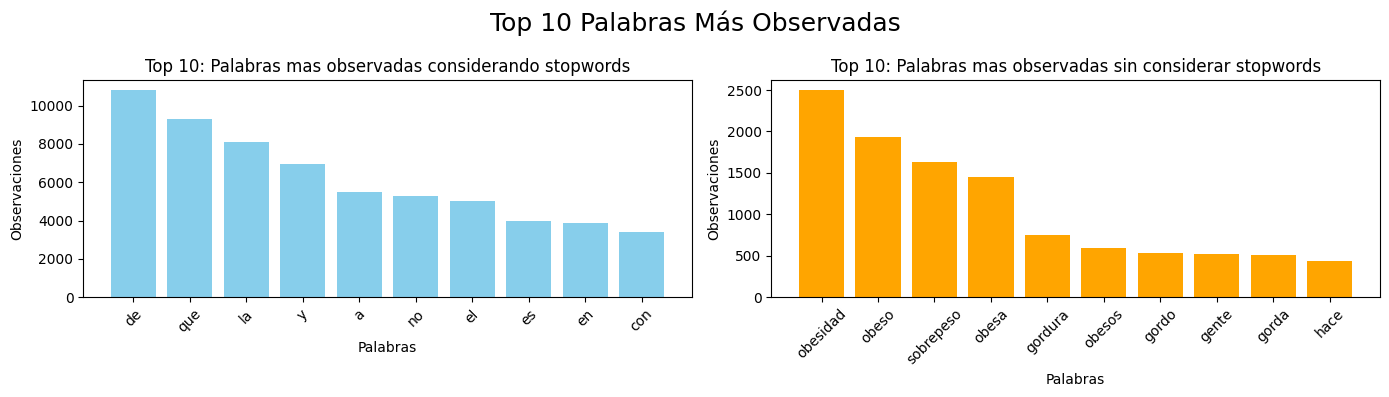

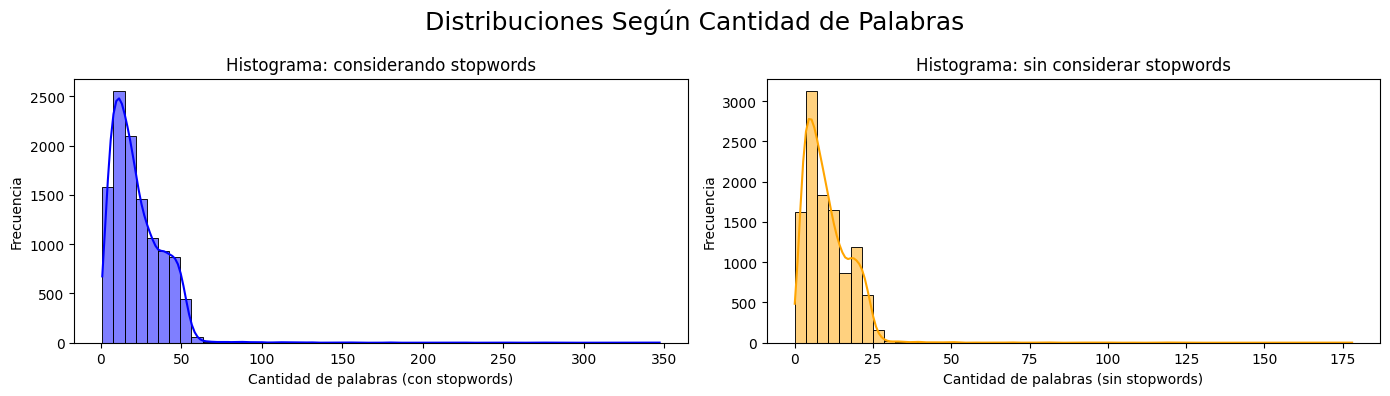

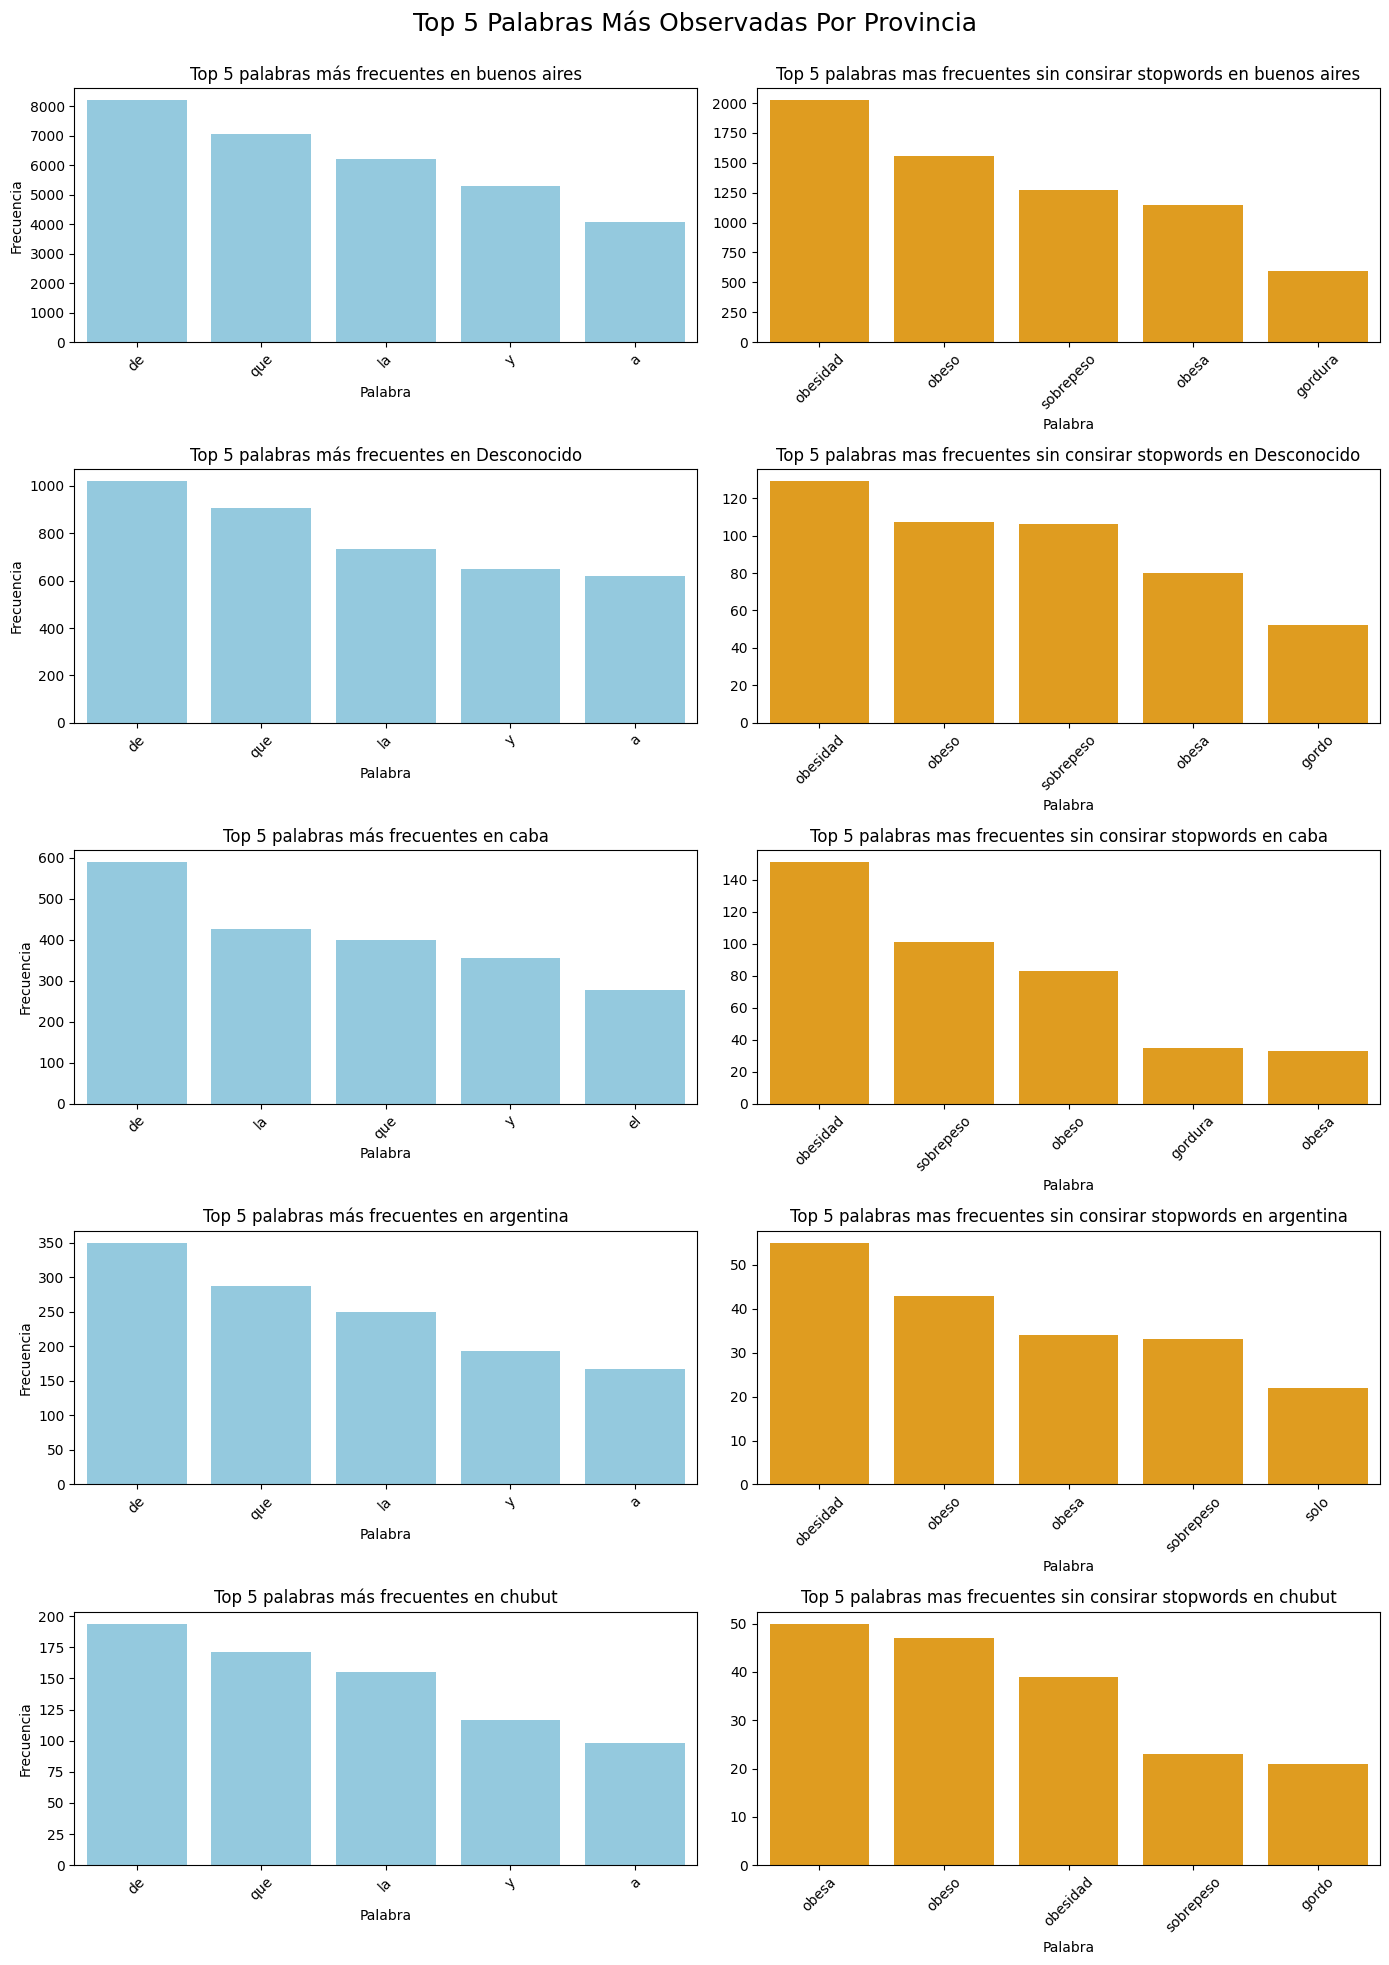

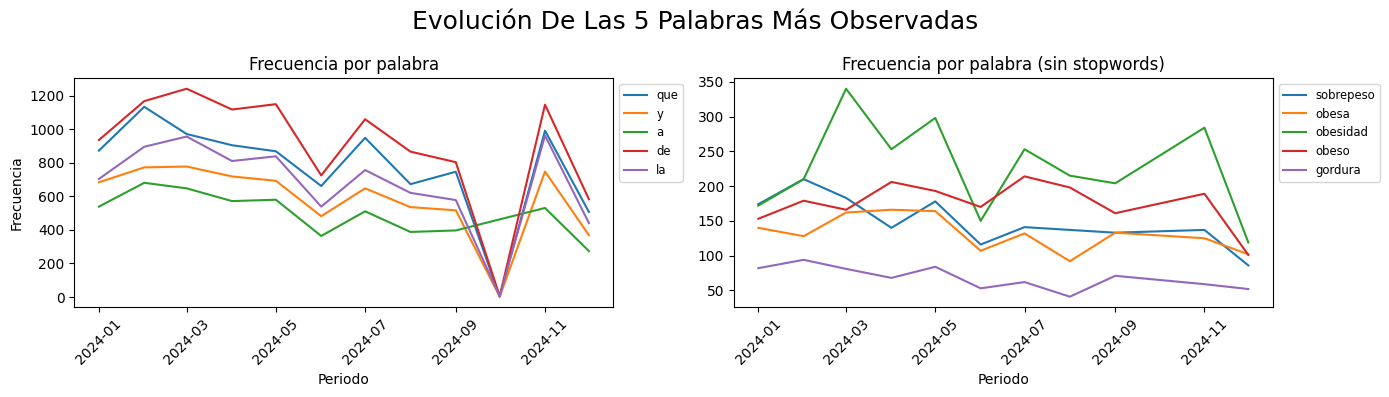

In [ ]:
def ejercicio_5_p1(df_):

    nltk.download('stopwords') # Usamos nlkt para obtener un set de stopwords del español que queremos evitar
    stop_words = set(stopwords.words('spanish'))

    # Diccionarios para conocer qué palabras se observan en la base de datos y cuál es su frecuencia en la muestra
    word_freq_raw = {}
    word_freq_no_stopwords = {}

    # Listas para conocer cantidad de palabras por tweet
    count_words_raw_list = []
    count_words_no_stopwords_list = []

    for tweet in df_['rawContent']:
        count_words_raw = 0
        count_words_no_stopwords = 0

        for word in tweet.split(' '):
            count_words_raw += 1 # Punto 5.c
            
            # Limpiamos y homologamos: Evitamos números, quitamos tildes y puntuación. Pasamos todo a minusc.
            word = re.sub(r'[^a-zA-Z_\s]', '', unicodedata.normalize('NFD', word).encode('ascii', 'ignore').decode('utf-8')).lower()
            
            if word == '' or word == 'link_url': # Evitamos cadenas vacías y otros
                continue
            
            word_freq_raw[word] = word_freq_raw.get(word, 0) + 1 # Punto 5.a
            
            if word not in stop_words and len(word) > 3: # Evitamos stopwords y palabras cortas (decisión)
                count_words_no_stopwords += 1 # Punto 5.c
                word_freq_no_stopwords[word] = word_freq_no_stopwords.get(word, 0) + 1 # Punto 5.b

        # Cant palabras por tweet
        count_words_raw_list.append(count_words_raw)
        count_words_no_stopwords_list.append(count_words_no_stopwords)

    # Guardamos para cada registro del df la cantidad de palabras del tweet (Punto 5.c)
    df_['count_words_raw'] = count_words_raw_list
    df_['count_words_no_stopwords'] = count_words_no_stopwords_list

    # Graficamos la frecuencia de las palabras considerando y obivando stopwrods:
    word_freq_raw = dict(sorted(word_freq_raw.items(), key=lambda item: item[1], reverse=True)) # Ordenamos el diccinario por cantidad de observaciones
    word_freq_raw_top_10 = list(word_freq_raw.items())[:10] # Muestra
    word_freq_raw_top_10_keys = [item[0] for item in word_freq_raw_top_10]
    word_freq_raw_top_10_values = [item[1] for item in word_freq_raw_top_10]

    word_freq_no_stopwords = dict(sorted(word_freq_no_stopwords.items(), key=lambda item: item[1], reverse=True)) # Ordenamos el diccinario por cantidad de observaciones
    word_freq_no_stopwords_top_10 = list(word_freq_no_stopwords.items())[:10] # Muestra
    word_freq_no_stopwords_top_10_keys = [item[0] for item in word_freq_no_stopwords_top_10]
    word_freq_no_stopwords_top_10_values = [item[1] for item in word_freq_no_stopwords_top_10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(word_freq_raw_top_10_keys, 
                word_freq_raw_top_10_values, 
                color='skyblue')
    axes[0].set_title('Top 10: Palabras mas observadas considerando stopwords')
    axes[0].set_xlabel('Palabras')
    axes[0].set_ylabel('Observaciones')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(word_freq_no_stopwords_top_10_keys, 
                word_freq_no_stopwords_top_10_values, 
                color='orange')
    axes[1].set_title('Top 10: Palabras mas observadas sin considerar stopwords')
    axes[1].set_xlabel('Palabras')
    axes[1].set_ylabel('Observaciones')
    axes[1].tick_params(axis='x', rotation=45)

    fig.suptitle("Top 10 Palabras Más Observadas", fontsize=18)
    plt.tight_layout()
    plt.show()

    # Graficamos las distribuciones considerando stopwrods y obviandolas: (Punto 5.c)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4)) 
    sns.histplot(data=df_, 
                x='count_words_raw', 
                bins=50, 
                kde=True, 
                color='blue',
                ax=axes[0])
    axes[0].set_title('Histograma: considerando stopwords')
    axes[0].set_xlabel('Cantidad de palabras (con stopwords)')
    axes[0].set_ylabel('Frecuencia')

    sns.histplot(data=df_, 
                x='count_words_no_stopwords', 
                bins=50, 
                kde=True, 
                color='orange',
                ax=axes[1])
    axes[1].set_title('Histograma: sin considerar stopwords')
    axes[1].set_xlabel('Cantidad de palabras (sin stopwords)')
    axes[1].set_ylabel('Frecuencia')

    fig.suptitle("Distribuciones Según Cantidad de Palabras", fontsize=18)
    plt.tight_layout()
    plt.show()

    word_freq_raw_pcia = {}
    word_freq_no_stopwords_pcia = {}

    for index, row in df_.iterrows():
        tweet_content = row['rawContent']
        provinces = row['pcia'].replace("'", '').replace('[', '').replace(']', '') # TODO: mejorar

        cleaned_tweet_content = re.sub(r'[^a-zA-Z_\s]', '', unicodedata.normalize('NFD', tweet_content).encode('ascii', 'ignore').decode('utf-8')).lower()

        # Dividir el tweet en palabras limpias
        words = cleaned_tweet_content.split(' ')

        # Ahora, para cada palabra limpia, la asociamos con CADA provincia en la lista 'provinces'
        for word in words:
            if word == '' or word == 'link_url': # Evitamos cadenas vacías y 'link_url'
                continue
            
            # Iterar sobre cada provincia asociada a este tweet
            for pcia_name in provinces.split(','):
                if pcia_name == '':
                    pcia_name = 'Desconocido'
                # Asegurarse de que pcia_name sea un string, no una lista o un elemento inesperado
                if not isinstance(pcia_name, str):
                    continue # O manejar el error/ignorar si no es un string válido

                # Contar la palabra para la provincia actual (sin filtros)
                word_freq_raw_pcia[(pcia_name, word)] = word_freq_raw_pcia.get((pcia_name, word), 0) + 1
                
                # Contar la palabra si no es una stopword y tiene longitud > 3
                if word not in stop_words and len(word) > 3:
                    word_freq_no_stopwords_pcia[(pcia_name, word)] = word_freq_no_stopwords_pcia.get((pcia_name, word), 0) + 1

    word_freq_raw_pcia = [(provincia, palabra, frecuencia) for (provincia, palabra), frecuencia in word_freq_raw_pcia.items()]
    word_freq_raw_pcia = pd.DataFrame(word_freq_raw_pcia, columns=['provincia', 'palabra', 'frecuencia'])

    word_freq_no_stopwords_pcia = [(provincia, palabra, frecuencia) for (provincia, palabra), frecuencia in word_freq_no_stopwords_pcia.items()]
    word_freq_no_stopwords_pcia = pd.DataFrame(word_freq_no_stopwords_pcia, columns=['provincia', 'palabra', 'frecuencia'])

    pcias = []
    for pcia in df['pcia'].value_counts().head(5).index:
        if pcia.replace("'", '').replace('[', '').replace(']', '') == '':
            pcias.append('Desconocido')
        else:
            pcias.append(pcia.replace("'", '').replace('[', '').replace(']', ''))

    top_words_raw_per_provincia = (
        word_freq_raw_pcia
        .sort_values(['provincia', 'frecuencia'], ascending=[True, False])
        .groupby('provincia')
        .head(5)
        .reset_index(drop=True)
    )
    top_words_raw_per_provincia = top_words_raw_per_provincia[top_words_raw_per_provincia['provincia'].isin(pcias)]

    top_words_no_stopword_per_provincia = (
        word_freq_no_stopwords_pcia
        .sort_values(['provincia', 'frecuencia'], ascending=[True, False])
        .groupby('provincia')
        .head(5)
        .reset_index(drop=True)
    )
    top_words_no_stopword_per_provincia = top_words_no_stopword_per_provincia[top_words_no_stopword_per_provincia['provincia'].isin(pcias)] 

    fig, axes = plt.subplots(5, 2, figsize=(14, 4*5), sharey=False)
    for i, pcia in enumerate(pcias):
        data_raw = top_words_raw_per_provincia[top_words_raw_per_provincia['provincia'] == pcia]
        data_no_stopwords = top_words_no_stopword_per_provincia[top_words_no_stopword_per_provincia['provincia'] == pcia]

        sns.barplot(
            data=data_raw,
            x='palabra',
            y='frecuencia',
            color='skyblue',
            ax=axes[i, 0]
        )
        axes[i, 0].set_title(f'Top 5 palabras más frecuentes en {pcia}')
        axes[i, 0].set_xlabel('Palabra')
        axes[i, 0].set_ylabel('Frecuencia')
        axes[i, 0].tick_params(axis='x', rotation=45)

        sns.barplot(
            data=data_no_stopwords,
            x='palabra',
            y='frecuencia',
            color='orange',
            ax=axes[i, 1]
        )
        axes[i, 1].set_title(f'Top 5 palabras mas frecuentes sin consirar stopwords en {pcia}')
        axes[i, 1].set_xlabel('Palabra')
        axes[i, 1].set_ylabel('')  # No repetimos "Frecuencia" para el segundo eje
        axes[i, 1].tick_params(axis='x', rotation=45)

    fig.suptitle("Top 5 Palabras Más Observadas Por Provincia", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) #[left, bottom, right, top]
    plt.show()

    word_freq_raw_mes = {}
    word_freq_no_stopwords_mes = {}

    for index, row in df_.iterrows():
        tweet_content = row['rawContent']
        periodo = row['date'].split('-')
        periodo = periodo[0] + '-' + periodo[1]

        cleaned_tweet_content = re.sub(r'[^a-zA-Z_\s]', '', unicodedata.normalize('NFD', tweet_content).encode('ascii', 'ignore').decode('utf-8')).lower()
        words = cleaned_tweet_content.split(' ')

        # Ahora, para cada palabra limpia, la asociamos con CADA provincia en la lista 'provinces'
        for word in words:
            if word == '' or word == 'link_url': # Evitamos cadenas vacías y 'link_url'
                continue

            word_freq_raw_mes[(periodo, word)] = word_freq_raw_mes.get((periodo, word), 0) + 1
            
            # Contar la palabra si no es una stopword y tiene longitud > 3
            if word not in stop_words and len(word) > 3:
                word_freq_no_stopwords_mes[(periodo, word)] = word_freq_no_stopwords_mes.get((periodo, word), 0) + 1

    word_freq_raw_mes = [(periodo, palabra, frecuencia) for (periodo, palabra), frecuencia in word_freq_raw_mes.items()]
    word_freq_raw_mes = pd.DataFrame(word_freq_raw_mes, columns=['periodo', 'palabra', 'frecuencia'])
    word_freq_raw_mes = word_freq_raw_mes[word_freq_raw_mes['palabra'].isin(word_freq_raw_top_10_keys[:5])] # Limitamos a las palabras de mayor ocurrencia general
    word_freq_raw_mes['periodo'] = pd.to_datetime(word_freq_raw_mes['periodo'], format='%Y-%m') 
    word_freq_raw_mes.sort_values('periodo', inplace=True)

    word_freq_no_stopwords_mes = [(periodo, palabra, frecuencia) for (periodo, palabra), frecuencia in word_freq_no_stopwords_mes.items()]
    word_freq_no_stopwords_mes = pd.DataFrame(word_freq_no_stopwords_mes, columns=['periodo', 'palabra', 'frecuencia'])
    word_freq_no_stopwords_mes = word_freq_no_stopwords_mes[word_freq_no_stopwords_mes['palabra'].isin(word_freq_no_stopwords_top_10_keys[:5])] # Limitamos a las palabras de mayor ocurrencia general
    word_freq_no_stopwords_mes['periodo'] = pd.to_datetime(word_freq_no_stopwords_mes['periodo'], format='%Y-%m')
    word_freq_no_stopwords_mes.sort_values('periodo', inplace=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    for palabra in word_freq_raw_mes['palabra'].unique():
        df_palabra = word_freq_raw_mes[word_freq_raw_mes['palabra'] == palabra]
        axes[0].plot(df_palabra['periodo'], df_palabra['frecuencia'], label=palabra)

    axes[0].set_title('Frecuencia por palabra')
    axes[0].set_xlabel('Periodo')
    axes[0].set_ylabel('Frecuencia')
    axes[0].tick_params(axis='x', rotation=45)
    #axes[0].set_yscale('log') # Podría mejorar la visualización
    axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

    for palabra in word_freq_no_stopwords_mes['palabra'].unique():
        df_palabra = word_freq_no_stopwords_mes[word_freq_no_stopwords_mes['palabra'] == palabra]
        axes[1].plot(df_palabra['periodo'], df_palabra['frecuencia'], label=palabra)

    axes[1].set_title('Frecuencia por palabra (sin stopwords)')
    axes[1].set_xlabel('Periodo')
    axes[1].tick_params(axis='x', rotation=45)
    #axes[1].set_yscale('log') # Podría mejorar la visualización
    axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

    fig.suptitle("Evolución De Las 5 Palabras Más Observadas", fontsize=18)
    plt.tight_layout()
    plt.show()

ejercicio_5_p1(df)

In [ ]:
# TODO: interpretación de los graficos| otras variables | procesos de curación

### Análisis estadístico

#### Ejercicio 6

Se comenzará el plan de análisis que será desarrollado a lo largo de los tres prácticos. En esta primera parte más introductoria les propongo:

* a. Reconocer posibles correlaciones entre variables. ¿En qué supuesto se basan?. Luego de aplicar el test estadístico interpretar los resultados y fundamentar la elección del mismo a partir de la naturaleza de los datos. No duden en consultarme ante cualquier inconveniente en este punto!

### Ejercicio final

* ¿Qué hallazgos te parecieron más interesantes?
* ¿Qué hipótesis o líneas de análisis podrías plantear a partir de lo visto?
* A partir del ejercicio 5. ¿Qué otras variables o aspectos sería útil incorporar en el análisis?


La fecha de entrega del práctico es para el día 30/6, la semana del 16/6 tendremos una instancia de consulta con cada grupo para ver como vienen con el práctico. El entregable será una notebook, vayan realizando visualizaciones pensando en la presentación de video posterior al segundo práctico.
Recuerden que es una instancia de aprendizaje por lo cual no duden en consultar lo que necesiten para resolver el práctico.  

Les dejo disponibles algunos recursos de introducción al NLP y text mining que podrían ser de utilidad.

NLP avanzado con spacy: https://course.spacy.io/es/